# Discrete Time Finance 2

This notebook continues the discrete-time coursework with wealth-process construction, constant-mix strategies, limit behavior in binomial models, and related exercises.

It is best read after the first discrete-time notebook.


# Programming Sheet 2

In [4]:
import numpy as np
import pandas as pd
from scipy.stats import rv_discrete
from scipy.stats import binom
import matplotlib.pyplot as plt
from scipy.stats import norm

In [5]:
# Display the DataFrame (adjust display settings)
pd.set_option('display.max_rows', 20)       # Maximum rows to display
pd.set_option('display.max_columns', 20)   # Maximum columns to display
pd.set_option('display.width', 200)        # Adjust width of the display
pd.set_option('display.precision', 2)      # Set precision for floating points

## Exercise 1: Wealth Process, Constant Max Strategy

### a) Binomial Tree as Matrix

In [160]:
def binomial_tree(T, n, r, sigma, P0):
    dt = T / n
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    rt = (1 + r)**dt - 1
    P = np.zeros((n + 1, n + 1))
    for j in range(n + 1):
        for i in range(0, j + 1):
            P[i, j] = P0 * d**i * u**(j-i)
    return P

### b) Constant Mix Strategy

In [ ]:
def constant_mix(T, n, r, sigma, V0):
    dt = T / n
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    rt = (1 + r)**dt - 1
    unew = (1 + r + u) / 2
    dnew = (1 + r + d) / 2
    V = np.zeros((n + 1, n + 1))
    for j in range(n + 1):
        for i in range(0, j + 1):
            V[i, j] = V0 * dnew**i * unew**(j - i)
    return V

### c) Test

In [162]:
r = 0.02
sigma = 0.2
T = 1
n = 100

In [163]:
tree = binomial_tree(T, n, r, sigma, 100)

df = pd.DataFrame(tree)
print(df)

       0       1       2       3       4       5       6       7       8       9    ...     91      92      93      94      95      96      97      98      99      100
0    100.0  102.02  104.08  106.18  108.33  110.52  112.75  115.03  117.35  119.72  ...  617.19  629.65  642.37  655.35  668.59  682.10  695.88  709.93  724.27  738.91
1      0.0   98.02  100.00  102.02  104.08  106.18  108.33  110.52  112.75  115.03  ...  592.99  604.96  617.19  629.65  642.37  655.35  668.59  682.10  695.88  709.93
2      0.0    0.00   96.08   98.02  100.00  102.02  104.08  106.18  108.33  110.52  ...  569.73  581.24  592.99  604.96  617.19  629.65  642.37  655.35  668.59  682.10
3      0.0    0.00    0.00   94.18   96.08   98.02  100.00  102.02  104.08  106.18  ...  547.39  558.45  569.73  581.24  592.99  604.96  617.19  629.65  642.37  655.35
4      0.0    0.00    0.00    0.00   92.31   94.18   96.08   98.02  100.00  102.02  ...  525.93  536.56  547.39  558.45  569.73  581.24  592.99  604.96  617.19 

In [164]:
wealth = constant_mix(T, n, r, sigma, 100)
df = pd.DataFrame(wealth)
print(df)

       0       1       2       3       4       5       6       7       8       9    ...     91      92      93      94      95      96      97      98      99      100
0    100.0  101.02  102.05  103.09  104.14  105.20  106.28  107.36  108.46  109.56  ...  251.80  254.37  256.96  259.59  262.23  264.91  267.61  270.34  273.10  275.88
1      0.0   99.02  100.03  101.05  102.08  103.12  104.17  105.24  106.31  107.39  ...  246.82  249.33  251.88  254.45  257.04  259.66  262.31  264.99  267.69  270.42
2      0.0    0.00   98.05   99.05  100.06  101.08  102.11  103.15  104.20  105.27  ...  241.93  244.40  246.89  249.41  251.95  254.52  257.12  259.74  262.39  265.07
3      0.0    0.00    0.00   97.09   98.08   99.08  100.09  101.11  102.14  103.18  ...  237.14  239.56  242.00  244.47  246.96  249.48  252.03  254.60  257.19  259.82
4      0.0    0.00    0.00    0.00   96.14   97.12   98.11   99.11  100.12  101.14  ...  232.44  234.81  237.21  239.63  242.07  244.54  247.04  249.56  252.10 

## Exercise 2.2: Limit behavior of binomial model

### a) Terminal density

In [165]:
def StockPriceDensity(P0, r, u, d, n):
    q = (1 + r - d) / (u - d)

    support = [P0 * np.exp(np.log(u)*(i) + np.log(d)*(n-i)) for i in range(n + 1)]
    density = [binom.pmf(k=i, n=n, p=q) for i in range(n + 1)]
    
    return rv_discrete(name='StockPriceDensity', values = (support, density))

### b) Plotting the density function

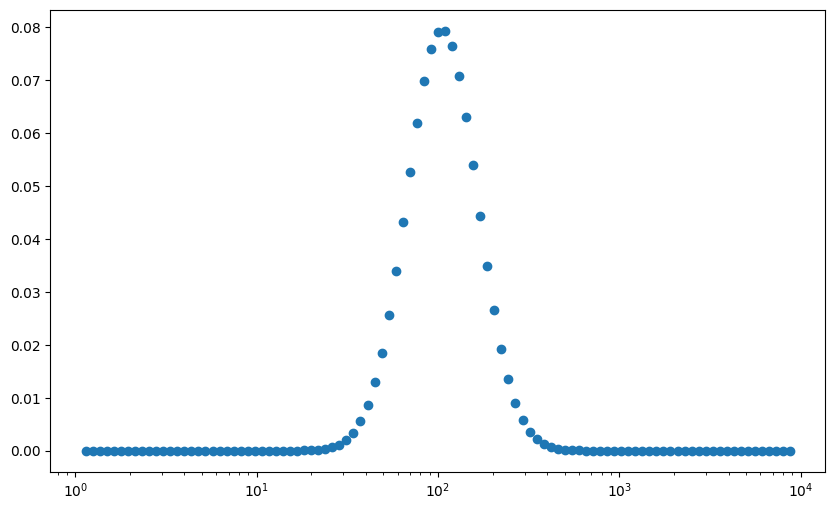

In [166]:
T = 5
r = 0.03
sigma = 0.2
P0 = 100
n = 100

dt = T / n
un = np.exp(sigma * np.sqrt(dt))
dn = 1 / un
rn = r * dt

# plot density
plt.figure(figsize=(10, 6))
support = [P0 * np.exp(np.log(un)*(i) + np.log(dn)*(n-i)) for i in range(n + 1)]
# only individual points where the density is non-zero and scale x-axis logarithmically
plt.plot(support, StockPriceDensity(P0, rn, un, dn, n).pmf(support), 'o', label='Density')
plt.xscale('log')


### c) Show $\tilde{Q}$ is risk-neutral measure

In [167]:
StockPriceDensity(P0, rn, un, dn, n).mean() / (1 + rn)**n

100.00000000000004

### d) Convergence plots of digital Call option: $K=P_1(0)$

In [168]:
def BSprice(P0, r, sigma, T, K):
    d1 = (np.log(P0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return np.exp(-r * T) * norm.cdf(d2)

In [169]:
def DiscretePrice(P0, rn, un, dn, n, K):
    return StockPriceDensity(P0, rn, un, dn, n).expect(lambda x: (x - K > 0) / (1 + rn)**n)

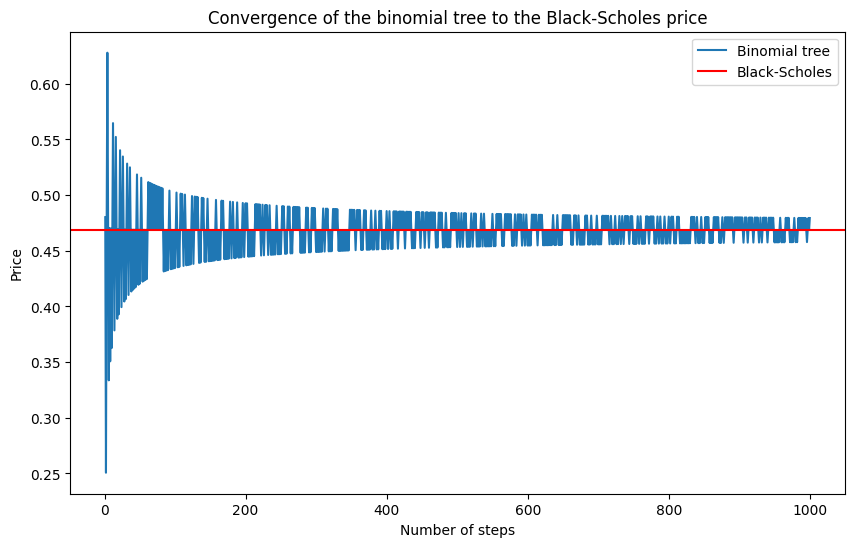

In [170]:
K = P0
N = 1000

plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, N + 1), [DiscretePrice(P0, r * T / ni, np.exp(sigma * np.sqrt(T / ni)), np.exp(-sigma * np.sqrt(T / ni)), ni, K) for ni in range(1, N + 1)], '-')
plt.axhline(y=BSprice(P0, r, sigma, T, K), color='r', linestyle='-')
plt.xlabel('Number of steps')
plt.ylabel('Price')
plt.title('Convergence of the binomial tree to the Black-Scholes price')
plt.legend(['Binomial tree', 'Black-Scholes'])
plt.show()

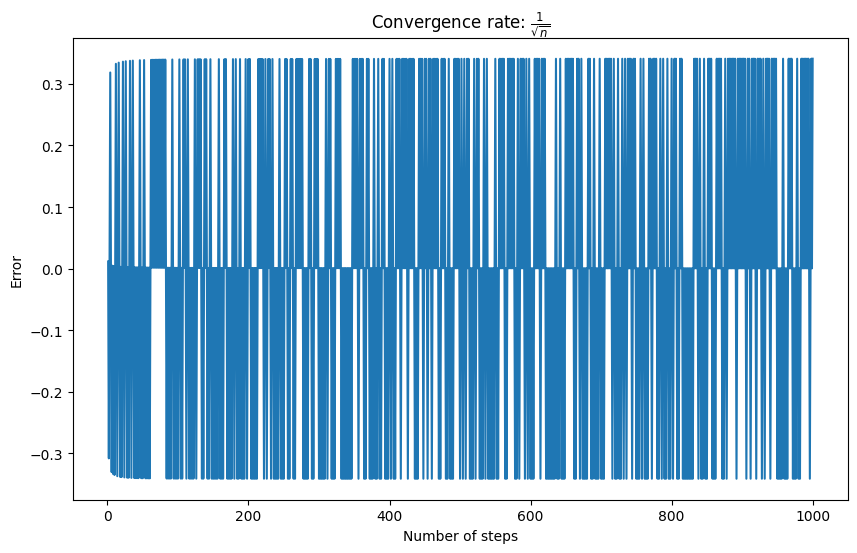

In [171]:
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, N + 1), [(DiscretePrice(P0, r * T / ni, np.exp(sigma * np.sqrt(T / ni)), np.exp(-sigma * np.sqrt(T / ni)), ni, K) - BSprice(P0, r, sigma, T, K)) * np.sqrt(ni) for ni in range(1, N + 1)], '-')
plt.xlabel('Number of steps')
plt.ylabel('Error')
plt.title(r"Convergence rate: $\frac{1}{\sqrt{n}}$")
plt.show()

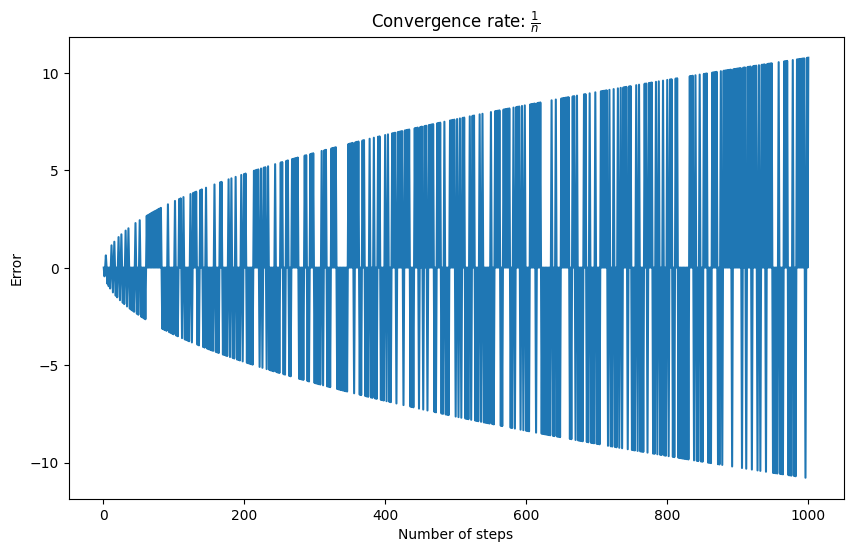

In [172]:
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, N + 1), [(DiscretePrice(P0, r * T / ni, np.exp(sigma * np.sqrt(T / ni)), np.exp(-sigma * np.sqrt(T / ni)), ni, K) - BSprice(P0, r, sigma, T, K)) * ni for ni in range(1, N + 1)], '-')
plt.xlabel('Number of steps')
plt.ylabel('Error')
plt.title(r"Convergence rate: $\frac{1}{n}$")
plt.show()

### e) Convergence plots of Digital Call option: $K=P_1(0)$; Odd Subsequence

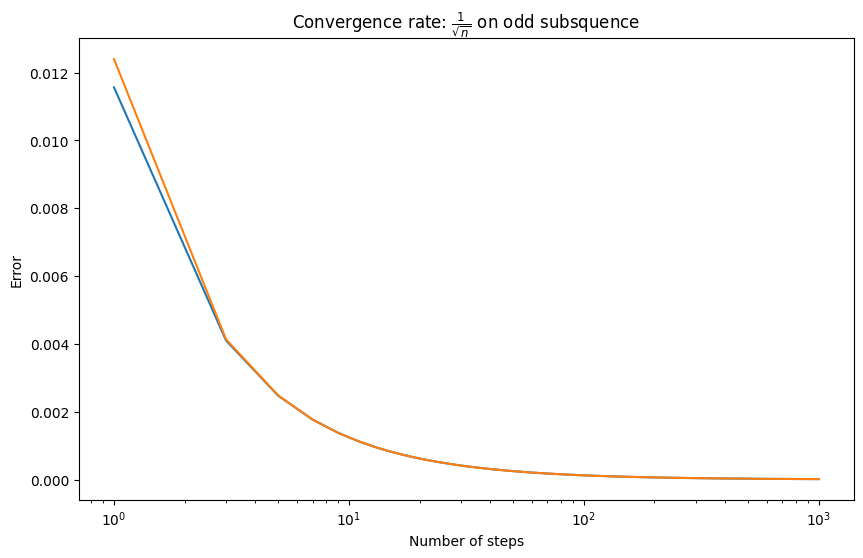

In [173]:
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, N, 2), [(DiscretePrice(P0, r * T / ni, np.exp(sigma * np.sqrt(T / ni)), np.exp(-sigma * np.sqrt(T / ni)), ni, K) - BSprice(P0, r, sigma, T, K)) for ni in range(1, N, 2)], '-')
plt.plot(np.arange(1, N, 2), [0.0124 / ni for ni in range(1, N, 2)], '-')
plt.xlabel('Number of steps')
plt.xscale('log')
plt.ylabel('Error')
plt.title(r"Convergence rate: $\frac{1}{\sqrt{n}}$ on odd subsquence")
plt.show()

### f) Convergence plots of Digital Call option: $K > P_1(0)$

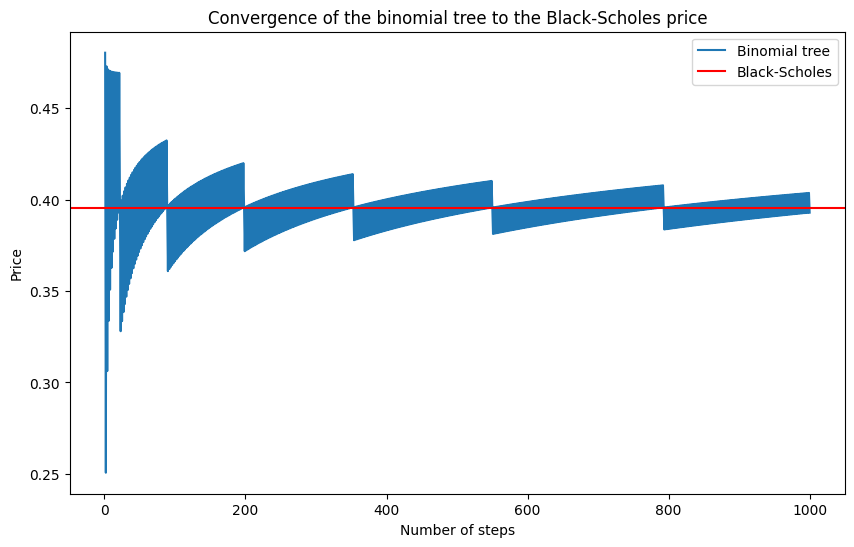

In [174]:
K = 1.1 * P0
N = 1000

plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, N + 1), [DiscretePrice(P0, r * T / ni, np.exp(sigma * np.sqrt(T / ni)), np.exp(-sigma * np.sqrt(T / ni)), ni, K) for ni in range(1, N + 1)], '-')
plt.axhline(y=BSprice(P0, r, sigma, T, K), color='r', linestyle='-')
plt.xlabel('Number of steps')
plt.ylabel('Price')
plt.title('Convergence of the binomial tree to the Black-Scholes price')
plt.legend(['Binomial tree', 'Black-Scholes'])
plt.show()

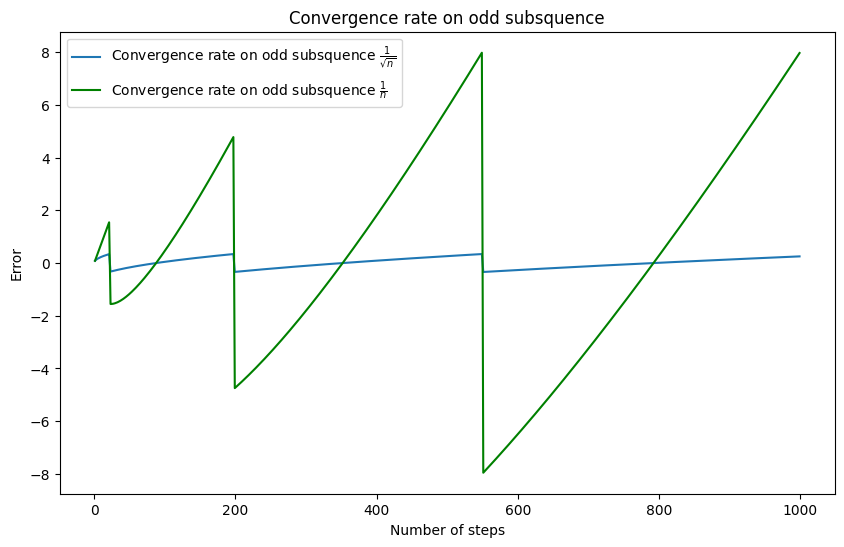

## Exercise 2.3: American Call option

In [10]:
T = 5
r = 0.03
sigma = 0.2
P0 = 100
n = 100

K = 1.1 * P0

un = np.exp(sigma * np.sqrt(T / n))
dn = 1 / un
rn = r * T / n

### a) Price Process

In [8]:
def binomial_tree(T, n, r, sigma, P0):
    dt = T / n
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    rt = (1 + r)**dt - 1
    P = np.zeros((n + 1, n + 1))
    for j in range(n + 1):
        for i in range(0, j + 1):
            P[i, j] = P0 * d**i * u**(j-i)
    return P

### b) American Payoffs

In [178]:
def American_Payoffs_tree(T, n, r, sigma, P0, K):
    tree = binomial_tree(T, n, r, sigma, P0)
    return np.maximum(tree - K, 0)

### c) Price American Call

In [179]:
def American_price(T, n, rn, sigma, P0, K):
    American_Payoffs = American_Payoffs_tree(T, n, r, sigma, P0, K)
    V = American_Payoffs
    dt = T / n
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    q = (1 + rn - d) / (u - d)
    for j in range(n - 1, -1, -1):
        for i in range(0, j + 1):
            V[i, j] = np.maximum(American_Payoffs[i, j], 1 / (1 + rn) * (q * V[i, j + 1] + (1 - q) * V[i + 1, j + 1]))
    return V

In [180]:
price = binomial_tree(T, n, rn, sigma, P0)
df = pd.DataFrame(price)
print(df)

       0       1       2       3       4       5       6       7       8       9    ...      91       92       93       94       95       96       97       98       99       100
0    100.0  104.57  109.36  114.36  119.59  125.06  130.78  136.76  143.01  149.55  ...  5853.61  6121.33  6401.30  6694.07  7000.24  7320.40  7655.21  8005.33  8371.47  8754.35
1      0.0   95.63  100.00  104.57  109.36  114.36  119.59  125.06  130.78  136.76  ...  5352.78  5597.60  5853.61  6121.33  6401.30  6694.07  7000.24  7320.40  7655.21  8005.33
2      0.0    0.00   91.44   95.63  100.00  104.57  109.36  114.36  119.59  125.06  ...  4894.80  5118.67  5352.78  5597.60  5853.61  6121.33  6401.30  6694.07  7000.24  7320.40
3      0.0    0.00    0.00   87.44   91.44   95.63  100.00  104.57  109.36  114.36  ...  4476.00  4680.72  4894.80  5118.67  5352.78  5597.60  5853.61  6121.33  6401.30  6694.07
4      0.0    0.00    0.00    0.00   83.62   87.44   91.44   95.63  100.00  104.57  ...  4093.04  4280.24  447

In [181]:
payoff = American_Payoffs_tree(T, n, rn, sigma, P0, K)
df = pd.DataFrame(payoff)
print(df)

     0    1    2     3     4      5      6      7      8      9    ...      91       92       93       94       95       96       97       98       99       100
0    0.0  0.0  0.0  4.36  9.59  15.06  20.78  26.76  33.01  39.55  ...  5743.61  6011.33  6291.30  6584.07  6890.24  7210.40  7545.21  7895.33  8261.47  8644.35
1    0.0  0.0  0.0  0.00  0.00   4.36   9.59  15.06  20.78  26.76  ...  5242.78  5487.60  5743.61  6011.33  6291.30  6584.07  6890.24  7210.40  7545.21  7895.33
2    0.0  0.0  0.0  0.00  0.00   0.00   0.00   4.36   9.59  15.06  ...  4784.80  5008.67  5242.78  5487.60  5743.61  6011.33  6291.30  6584.07  6890.24  7210.40
3    0.0  0.0  0.0  0.00  0.00   0.00   0.00   0.00   0.00   4.36  ...  4366.00  4570.72  4784.80  5008.67  5242.78  5487.60  5743.61  6011.33  6291.30  6584.07
4    0.0  0.0  0.0  0.00  0.00   0.00   0.00   0.00   0.00   0.00  ...  3983.04  4170.24  4366.00  4570.72  4784.80  5008.67  5242.78  5487.60  5743.61  6011.33
..   ...  ...  ...   ...   ...    

In [182]:
option_value = American_price(T, n, rn, sigma, P0, K)
df = pd.DataFrame(option_value)
print(df)

       0      1      2      3      4      5      6      7      8      9    ...      91       92       93       94       95       96       97       98       99       100
0    19.98  22.81  25.95  29.40  33.17  37.29  41.77  46.62  51.84  57.45  ...  5745.08  6012.64  6292.45  6585.06  6891.06  7211.06  7545.71  7895.66  8261.63  8644.35
1     0.00  17.14  19.68  22.50  25.62  29.06  32.83  36.94  41.42  46.26  ...  5244.25  5488.91  5744.76  6012.32  6292.12  6584.73  6890.73  7210.73  7545.38  7895.33
2     0.00   0.00  14.59  16.85  19.37  22.18  25.29  28.72  32.48  36.59  ...  4786.27  5009.98  5243.93  5488.58  5744.43  6011.99  6291.80  6584.40  6890.40  7210.40
3     0.00   0.00   0.00  12.33  14.32  16.56  19.07  21.86  24.96  28.38  ...  4367.48  4572.03  4785.95  5009.65  5243.60  5488.25  5744.10  6011.66  6291.47  6584.07
4     0.00   0.00   0.00   0.00  10.33  12.07  14.04  16.27  18.76  21.54  ...  3984.51  4171.55  4367.15  4571.70  4785.62  5009.33  5243.27  5487.93  574

In [183]:
def StockPriceDensity(P0, r, u, d, n):
    q = (1 + r - d) / (u - d)

    support = [P0 * np.exp(np.log(u)*(i) + np.log(d)*(n-i)) for i in range(n + 1)]
    density = [binom.pmf(k=i, n=n, p=q) for i in range(n + 1)]
    
    return rv_discrete(name='StockPriceDensity', values = (support, density))

In [184]:
StockPriceDensity(P0, rn, un, dn, n).expect(lambda x: np.maximum(x - K, 0) / (1 + rn)**n)

19.97613420540539

### Euro

In [24]:
def euroPayoffs(T, n, r, sigma, P0, K):
    E= binomial_tree(T, n, r, sigma, P0)
    tree = np.zeros((n+1,n+1))
    tree[:n+1, n] = np.maximum(E[:n+1, n] - K, 0.0)
    return tree

In [34]:
print(euroPayoffs(T, n, r, sigma, P0, K)[:n+1,n])

[8644.35124586 7895.33458763 7210.4033126  6584.07431664 6011.33362646
 5487.59626112 5008.66952767 4570.7194573  4170.24011307 3804.02552379
 3469.14401907 3162.91476036 2882.88627994 2626.81685607 2392.6565673
 2178.53088213 1982.72565277 1803.67339281 1639.94072898 1490.21692648
 1353.30339616 1228.10409938 1113.61677385 1008.92491021  913.19041504
  825.64690166  745.59355494  672.38952105  605.44877718  544.23544027
  488.25947707  437.07278126  390.26558619  347.46318461  308.32292896
  272.5314884   239.80234045  209.87347734  182.50530849  157.47874255
  134.59343349  113.66617674   94.52944262   77.03003514   61.02786571
   46.39483159   33.01379046   20.77762259    9.58837337    0.
    0.            0.            0.            0.            0.
    0.            0.            0.            0.            0.
    0.            0.            0.            0.            0.
    0.            0.            0.            0.            0.
    0.            0.            0.            0

In [60]:
def euroPrice(T, n, r, sigma, P0, K):
    X=euroPayoffs(T, n, r, sigma, P0, K)
    dt = T / n
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    rn = r * T / n
    q = (1 + rn - d) / (u - d)

    for j in range (n-1,-1,-1):
        for i in range(0,j+1):
            X[i,j]=np.maximum(1/(1+rn)*(q*X[i,j+1]+(1-q)*X[i+1,j+1]),0)
    return X

In [62]:
euroPrice(T, n, r, sigma, P0, K)[0,0]

19.976134205405312